In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
import pandas as pd


In [2]:
import src.preference_factors.build_datasets as bd

In [3]:
monthly_EBC_returns, weights_monthly, monthly_EBC_betas = bd.build_EBC_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

Rolling OLS CAPM:   0%|          | 0/702 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/702 [00:00<?, ?it/s]

/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:251: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  weights_rebal = full_weights.resample("Q").last()


In [4]:
turnover_m = weights_monthly.diff().abs().sum(axis=1)

# how many rebalancing months?
(turnover_m > 1e-8).sum()


231

In [5]:
rebal_dates = turnover_m[turnover_m > 1e-8].index
rebal_dates.to_series().diff().value_counts().head()


date
92 days    115
91 days     73
90 days     42
Name: count, dtype: int64

In [6]:
weights_monthly.loc["2015"].diff().abs().sum(axis=1)


date
2015-01-01    0.000000
2015-02-01    0.000000
2015-03-01    0.000000
2015-04-01    0.305183
2015-05-01    0.000000
2015-06-01    0.000000
2015-07-01    0.324967
2015-08-01    0.000000
2015-09-01    0.000000
2015-10-01    0.302729
2015-11-01    0.000000
2015-12-01    0.000000
Freq: MS, dtype: float64

<Figure size 1200x600 with 0 Axes>

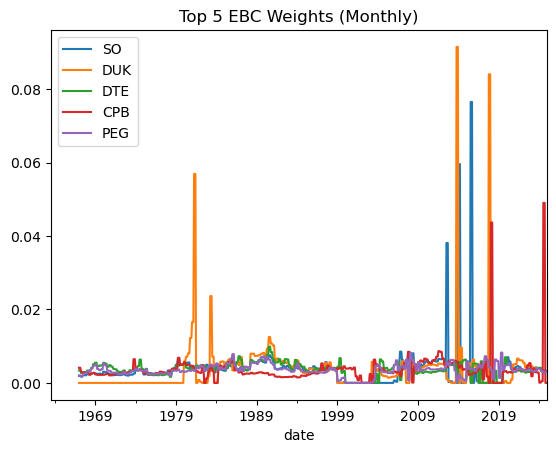

In [7]:
import matplotlib.pyplot as plt

avg_weights = weights_monthly.mean().sort_values(ascending=False)
top5 = avg_weights.head(5).index

plt.figure(figsize=(12,6))
weights_monthly[top5].plot()
plt.title("Top 5 EBC Weights (Monthly)")
plt.show()


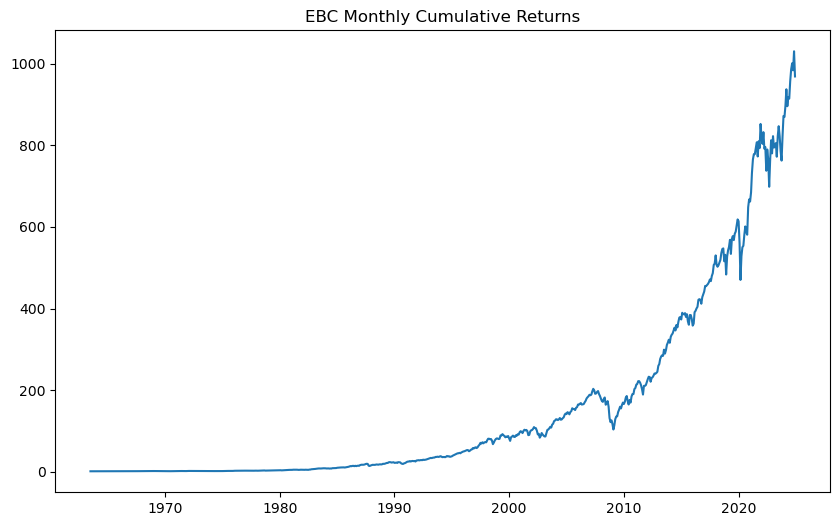

In [8]:
cum = (1 + monthly_EBC_returns["EBC_returns_monthly"]).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cum)
plt.title("EBC Monthly Cumulative Returns")
plt.show()


In [9]:
date = weights_monthly.index[100]

(weights_monthly.loc[date] * monthly_EBC_betas.loc[date]).sum()


0.0021971657506481904

In [46]:
monthly_EBC_returns

,EBC_returns_monthly
date,
1963-07-01,0.000000
1963-08-01,0.000000
1963-09-01,0.000000
1963-10-01,0.000000
1963-11-01,0.000000
...,...
2024-08-01,0.030822
2024-09-01,0.014868
2024-10-01,-0.017106


In [47]:
import importlib
import src.preference_factors.build_datasets as bd

importlib.reload(bd)


<module 'src.preference_factors.build_datasets' from '/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_datasets.py'>

In [48]:
from src.FamaMacBeth.betas import compute_rolling_betas
from src.FamaMacBeth.pipeline import run_full_factor_pipeline

merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

ebc = merged_df["EBC"]
cw_ebc = merged_df["CW-EBC"]


Rolling OLS CAPM:   0%|          | 0/702 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/702 [00:00<?, ?it/s]

/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:251: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  weights_rebal = full_weights.resample("Q").last()


In [49]:
full_merged_df

,CW,EW,EBC,CW-EW,CW-EBC,MKT_RF,SMB,HML,RMW,CMA,RF,MOM
date,,,,,,,,,,,,
1963-07,-0.000584,-0.011361,0.000000,0.010777,-0.000584,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08,0.054982,0.057987,0.000000,-0.003005,0.054982,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09,-0.008836,-0.019518,0.000000,0.010682,-0.008836,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10,0.038715,0.026247,0.000000,0.012468,0.038715,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11,-0.002799,-0.004267,0.000000,0.001468,-0.002799,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08,0.028116,0.024943,0.030822,0.003173,-0.002707,0.0161,-0.0355,-0.0110,0.0076,0.0082,0.0048,0.0481
2024-09,0.025856,0.023297,0.014868,0.002560,0.010989,0.0173,-0.0092,-0.0277,0.0020,-0.0029,0.0040,-0.0062
2024-10,-0.004786,-0.016410,-0.017106,0.011624,0.012320,-0.0100,-0.0089,0.0086,-0.0148,0.0098,0.0039,0.0300


In [50]:
cw_ebc

date
1963-07   -0.000584
1963-08    0.054982
1963-09   -0.008836
1963-10    0.038715
1963-11   -0.002799
             ...   
2024-08   -0.002707
2024-09    0.010989
2024-10    0.012320
2024-11    0.019080
2024-12    0.044735
Freq: M, Name: CW-EBC, Length: 738, dtype: float64

In [51]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

In [52]:
factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()
factor_returns

,EBC,CW-EBC
date,,
1963-07,0.000000,-0.000584
1963-08,0.000000,0.054982
1963-09,0.000000,-0.008836
1963-10,0.000000,0.038715
1963-11,0.000000,-0.002799
...,...,...
2024-08,0.030822,-0.002707
2024-09,0.014868,0.010989
2024-10,-0.017106,0.012320


In [53]:
asset_returns = bd.build_returns_dataset("sp500_returns_monthly_with_tickers.csv", frequency="monthly")
factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()
factor_returns.columns = ["EBC", "CW-EBC"]

asset_returns, factor_returns = asset_returns.align(factor_returns, join="inner", axis=0)

betas_ebc = compute_rolling_betas(asset_returns, ebc, rolling_window=36, min_obs=10)
betas_cw_ebc = compute_rolling_betas(asset_returns, cw_ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 702/702 [00:19<00:00, 36.92it/s]


In [54]:
print("asset_returns:", asset_returns.shape)
print("factor_returns:", factor_returns.shape)

combined = asset_returns.join(factor_returns, how="inner")
print("combined:", combined.shape)

print("intersection length:",
      len(asset_returns.index.intersection(factor_returns.index)))


asset_returns: (738, 1955)
factor_returns: (738, 2)
combined: (738, 1957)
intersection length: 738


In [128]:
import importlib

import src.FamaMacBeth.betas as betas_module
import src.FamaMacBeth.pipeline as pipeline_module

importlib.reload(betas_module)
importlib.reload(pipeline_module)

from src.FamaMacBeth.pipeline import run_full_factor_pipeline


In [178]:
import importlib
import src.FamaMacBeth.quantile as q
import src.FamaMacBeth.pipeline as p

importlib.reload(q)
importlib.reload(p)

from src.FamaMacBeth.pipeline import run_full_factor_pipeline


In [179]:
results = run_full_factor_pipeline(
    beta1_df=betas_ebc,
    beta2_df=betas_cw_ebc,
    sp500=asset_returns,
    EBC=factor_returns["EBC"],
    Cap_EBC=factor_returns["CW-EBC"],
    n_q1=3,
    n_q2=3,
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC",
    frequency = 'monthly',
    formation_frequency='monthly'
)

results["mean_grid"]

DatetimeIndex(['1966-07-01', '1966-08-01', '1966-09-01', '1966-10-01',
               '1966-11-01', '1966-12-01', '1967-01-01', '1967-02-01',
               '1967-03-01', '1967-04-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='date', length=702, freq='MS')


forming portfolios: 100%|██████████| 702/702 [00:09<00:00, 76.40it/s]


,1,2,3
1,0.011180,0.012192,0.013754
2,0.009863,0.011590,0.012003
3,0.009062,0.010193,0.010912


In [180]:
results['portrets_wide'][:5]

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
date,,,,,,,,,
1967-02-01,-0.018447,0.002302,0.010596,-0.003440,0.005162,0.002300,0.042267,0.008932,0.008390
1967-03-01,0.091311,0.053240,0.040993,0.056530,0.063016,0.032113,0.064879,0.035830,0.017060
1967-04-01,0.039538,0.037417,0.027162,0.037965,0.040415,0.026791,0.049073,0.028830,0.030946
1967-05-01,-0.022101,-0.041659,-0.033099,-0.013723,-0.034294,-0.013817,-0.034723,-0.019026,-0.028501
1967-06-01,0.052640,0.055660,0.055521,0.049225,0.028919,0.017022,0.017045,0.020125,0.016490


In [181]:
from pathlib import Path
import importlib
import src.FamaMacBeth.backtest as backtest
importlib.reload(backtest)
'''(
    load_monthly_inputs,
    backtest_quantile_portfolios,
    compute_excess_returns,
)
'''
import src.FamaMacBeth.plots as plots

importlib.reload(plots)

<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

In [182]:
# ============================
# USER PARAMETERS
# ============================
start_date = "1970-01-01"
use_excess_returns = True

# ============================
# REQUIRED INPUTS FROM PIPELINE
# ============================
members_df = results["members"]
n_q1, n_q2 = results["mean_grid"].shape

# ============================
# LOAD RETURNS / CAPS / RF
# ============================
DATA_RAW_DIR = Path.cwd().parent / "data" / "raw"
sp_500, sp_caps, rf = backtest.load_monthly_inputs(DATA_RAW_DIR)

In [183]:
# ============================
# RUN BACKTEST
# ============================
quantile_portfolios_returns = backtest.backtest_quantile_portfolios(
    members_df=members_df,
    returns_df=sp_500,
    caps_df=sp_caps,
    n_q1=n_q1,
    n_q2=n_q2,
    weight="cap",
)

if use_excess_returns:
    quantile_portfolios_returns = backtest.compute_excess_returns(
        quantile_portfolios_returns, rf, start_date=start_date
    )
else:
    quantile_portfolios_returns = quantile_portfolios_returns.loc[start_date:]

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

Q2 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

Q2 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

Q2 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

In [184]:
rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}

quantile_portfolios_returns = quantile_portfolios_returns.rename(columns=rename_map)


In [185]:
full_merged_df.index = full_merged_df.index.to_timestamp(how="start")
full_merged_df.index.name = "date"


AttributeError: 'DatetimeIndex' object has no attribute 'to_timestamp'

In [186]:
complete_df = full_merged_df.join(
    quantile_portfolios_returns,
    how="inner"
)


In [187]:
complete_df['CW-RF'] = complete_df['CW'] - complete_df['RF']

In [188]:
complete_df.columns

Index(['CW', 'EW', 'EBC', 'CW-EW', 'CW-EBC', 'MKT_RF', 'SMB', 'HML', 'RMW',
       'CMA', 'RF', 'MOM', 'EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low', 'CW-RF'],
      dtype='object')

In [189]:
selected_columns = ['CW-RF','EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low']

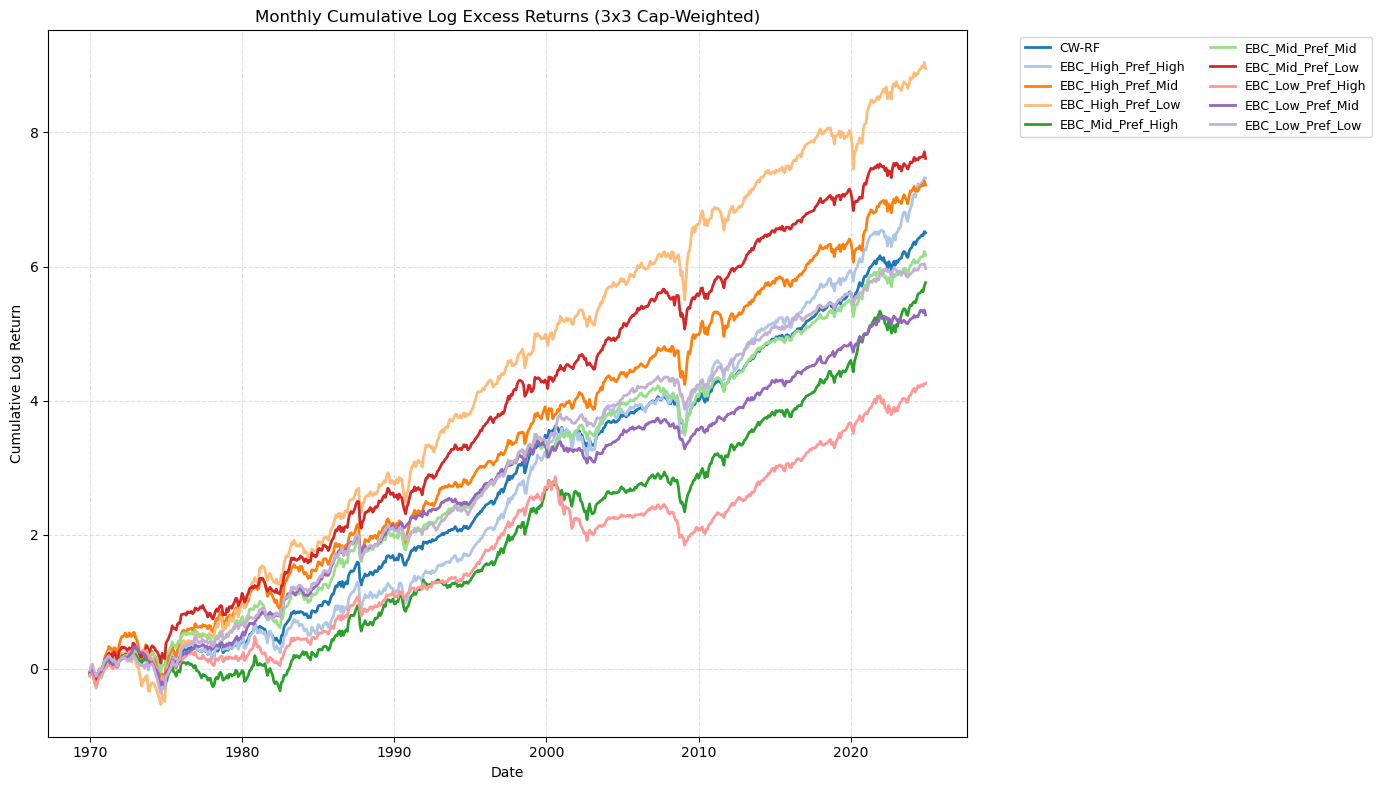

In [190]:
# ============================
# PLOTS
# ============================
plots.plot_cum_log_returns(
    complete_df[selected_columns],
    title=f"Monthly Cumulative Log Excess Returns ({n_q1}x{n_q2} Cap-Weighted)",
)

In [191]:
results["pricing"]

,mean_return,betaEBC,betaCap_EBC,alpha_ts,alpha_fm
portfolio,,,,,
Q1_Q1,0.011180,1.356836,0.668392,-0.005715,0.000077
Q1_Q2,0.012192,1.355910,-0.121180,-0.001992,-0.000363
Q1_Q3,0.013754,1.453117,-0.449271,-0.000354,0.000211
Q2_Q1,0.009863,1.147324,0.832799,-0.005338,-0.000110
Q2_Q2,0.011590,1.077498,-0.023737,0.000070,0.000314
Q2_Q3,0.012003,1.107964,-0.400762,0.001445,-0.000089
Q3_Q1,0.009062,0.946044,0.909745,-0.004236,0.000025
Q3_Q2,0.010193,0.783221,-0.044896,0.001914,0.000039
Q3_Q3,0.010912,0.834890,-0.401489,0.003296,-0.000104


In [192]:
results_trimmed = results['portrets_wide'].loc['2000-01':]


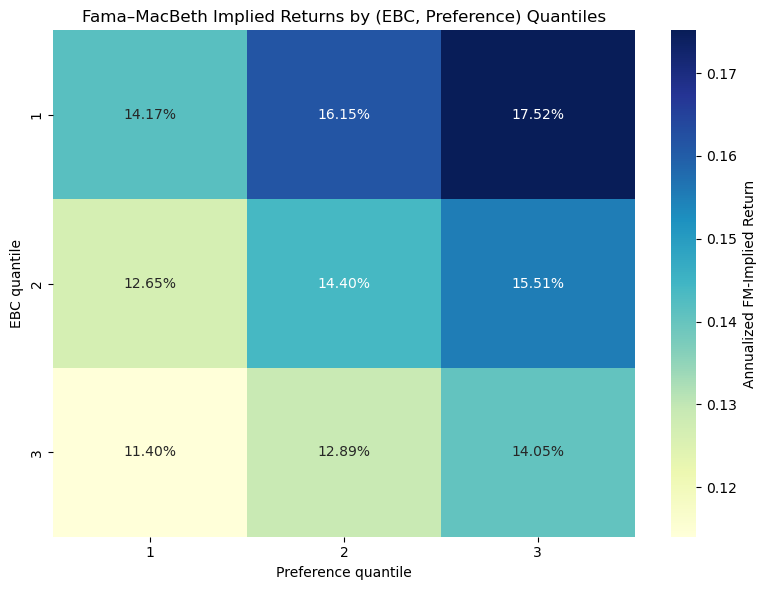

,1,2,3
1,0.141679,0.161505,0.175181
2,0.126467,0.144035,0.155149
3,0.114005,0.128896,0.140498


In [193]:
# FM expected-return grid (annualized %)
plots.plot_expected_return_grid(results["pricing"], results["fm_table"], n_q1, n_q2)

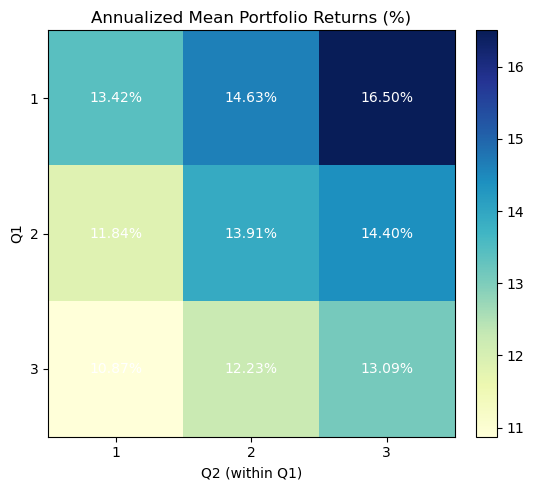

,1,2,3
1,13.416218,14.630060,16.504307
2,11.836172,13.908048,14.403760
3,10.874541,12.231937,13.093993


In [194]:
plots.plot_mean_grid(results["mean_grid"], annualize=True)

In [195]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [196]:
quantile_portfolios_returns.index = (
    quantile_portfolios_returns.index.to_period("M")
)
quantile_portfolios_returns.index.name = "date"


In [197]:
quantile_portfolios_returns.to_csv(DATA_PROCESSED_DIR / "monthly_quantile_returns_3x3.csv")

## Fitted GARCH

In [198]:
from arch import arch_model
import numpy as np
import matplotlib.pyplot as plt


In [199]:
def fit_garch_model(returns):
    """
    Fit GARCH(1,1) with student t errors
    """

    returns = returns.dropna()

    # Scale to percentage
    returns_scaled = returns * 100

    am = arch_model(
        returns_scaled,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    res = am.fit(disp="off")

    return res


In [200]:
complete_df.columns

Index(['CW', 'EW', 'EBC', 'CW-EW', 'CW-EBC', 'MKT_RF', 'SMB', 'HML', 'RMW',
       'CMA', 'RF', 'MOM', 'EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low', 'CW-RF'],
      dtype='object')

In [201]:
portfolio_name = 'CW-RF'

In [202]:
EBC_we

NameError: name 'EBC_we' is not defined

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        CW-RF   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1883.22
Distribution:      Standardized Student's t   AIC:                           3776.44
Method:                  Maximum Likelihood   BIC:                           3798.91
                                              No. Observations:                  660
Date:                      Mon, Feb 16 2026   Df Residuals:                      659
Time:                              02:49:27   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             1

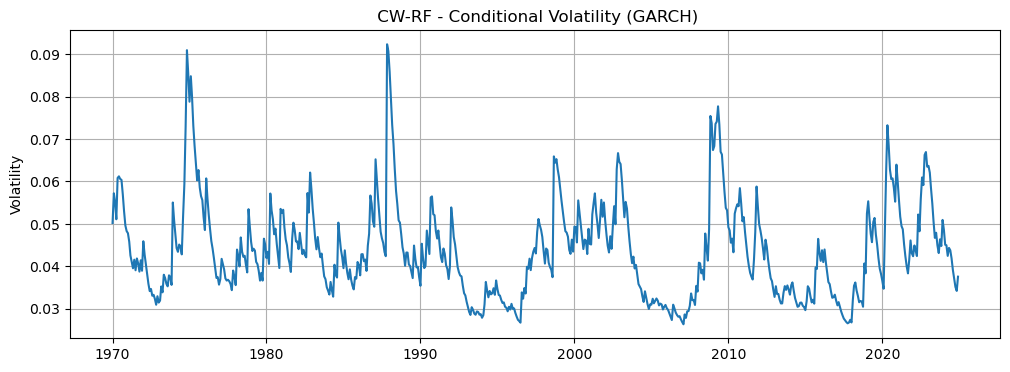

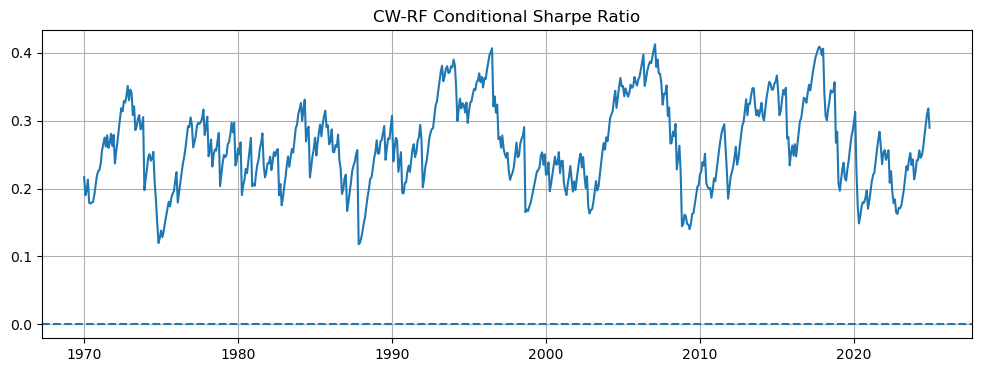

In [203]:
portfolio = complete_df[portfolio_name]

garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title(f" {portfolio_name} - Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title(f"{portfolio_name} Conditional Sharpe Ratio")
plt.grid(True)
plt.show()



